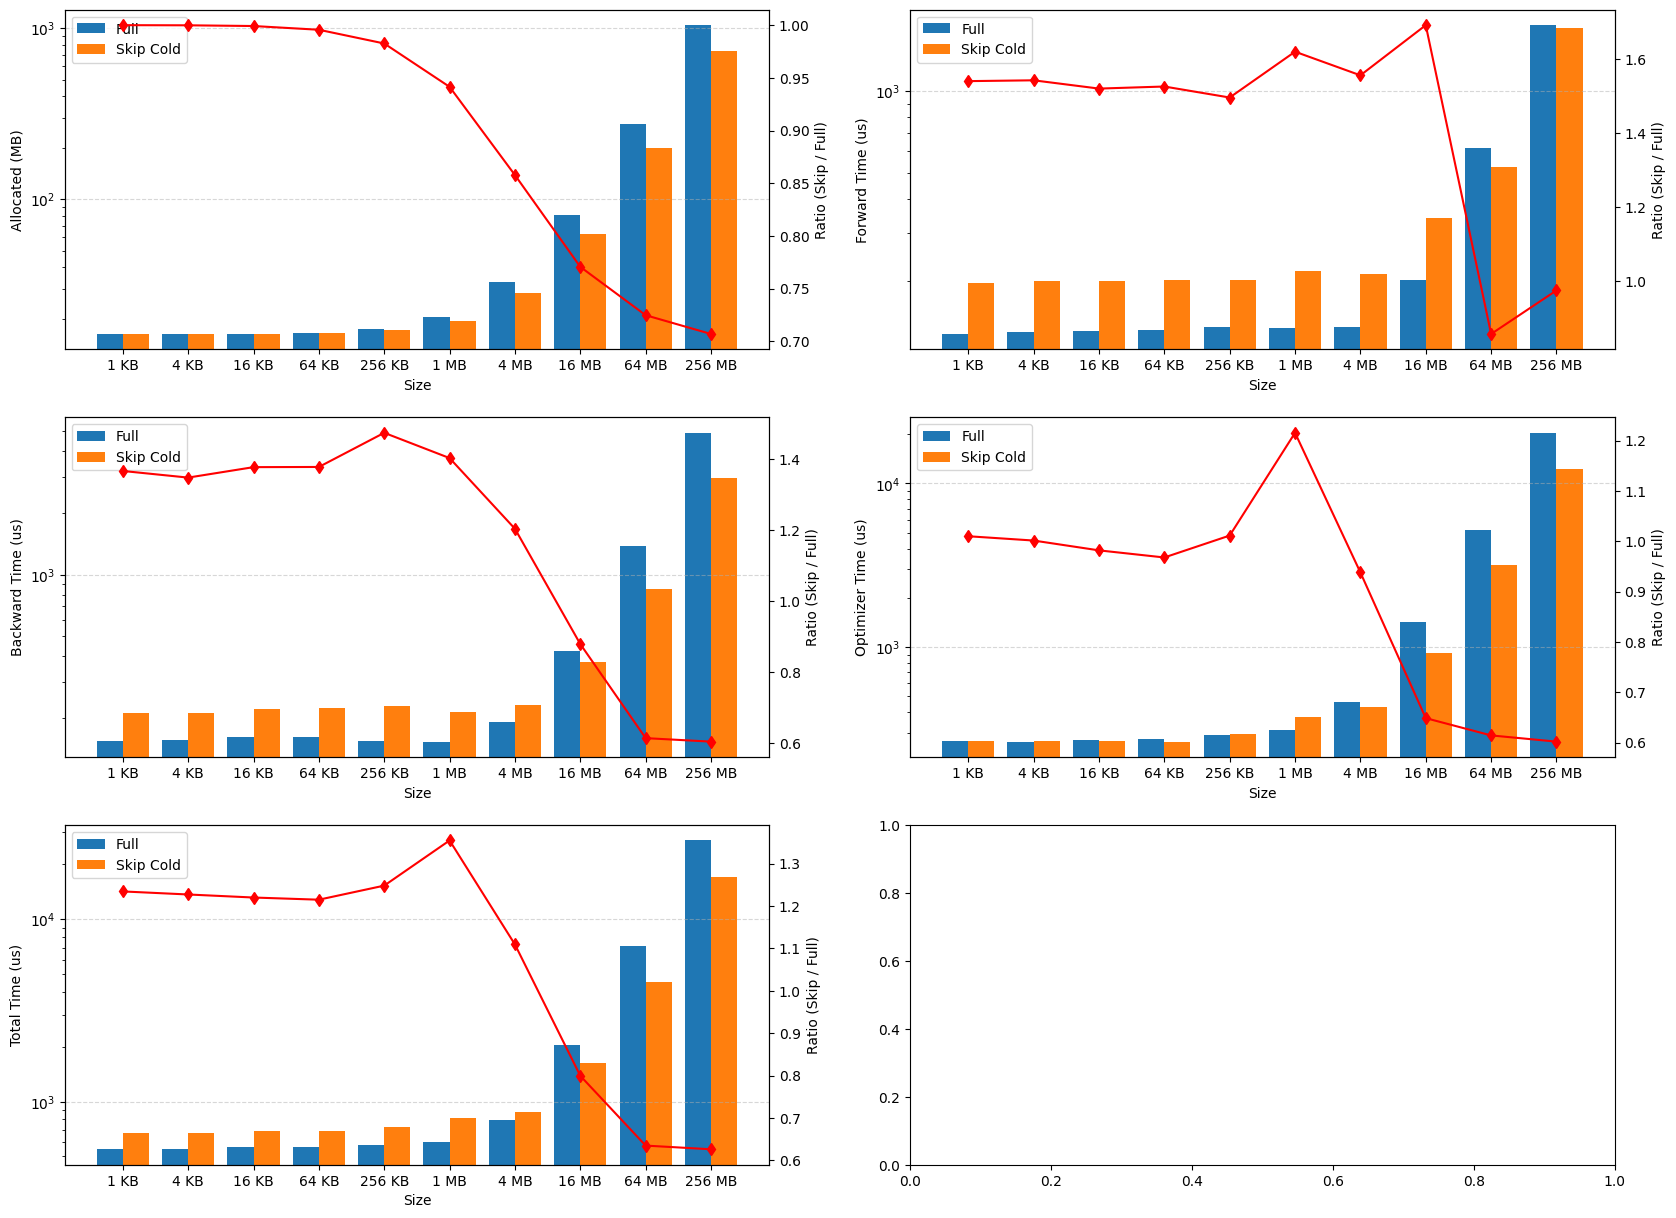

In [72]:
from pprint import pprint
hot_ratio=0.2

csv_path = "./performance/benchmark_results.csv"   # <- change to your file path
cols = ["in_dim","out_dim","hidden_dim","skip","hot_ratio",
        "Allocated (MB)","cached_MB","Forward Time (us)","Backward Time (us)","Optimizer Time (us)"]
df = pd.read_csv(csv_path, header=None, names=cols)
# print(df.head())

# --- Prepare data ---
# X value in BYTES: hidden_dim * out_dim * 4
df["size_bytes"] = df["hidden_dim"] * df["out_dim"] * 4
df["Total Time (us)"] = df["Forward Time (us)"] + df["Backward Time (us)"] + df["Optimizer Time (us)"]

metrics = ["Allocated (MB)", "Forward Time (us)", "Backward Time (us)", "Optimizer Time (us)", "Total Time (us)"]
perf = {} # metric -> (sizes, vals_false, vals_true)
for metric in metrics:
        # Aggregate in case multiple trials per config
        g = (df.groupby(["size_bytes","skip"], as_index=False)
                .agg(**{metric: (metric,"mean")}))
        
        # Pivot to have columns for skip=False / skip=True
        wide = g.pivot(index="size_bytes", columns="skip", values=metric).sort_index()
        # Ensure both columns exist
        if True not in wide.columns:  wide[True]  = np.nan
        if False not in wide.columns: wide[False] = np.nan
        wide = wide.rename(columns={False:"skip=False", True:"skip=True"})
        
        sizes = wide.index.values.astype(float)
        vals_false = wide["skip=False"].values
        vals_true  = wide["skip=True"].values
        
        perf[metric] = (sizes, vals_false, vals_true)


# 4 subfigures, two in one row
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    sizes, vals_false, vals_true = perf[metric]
    
    x = np.arange(len(sizes))
    bar_w = 0.4

    ax.bar(x - bar_w/2, vals_false, width=bar_w, label="Full")
    ax.bar(x + bar_w/2, vals_true, width=bar_w, label="Skip Cold")

    ax.set_xlabel("Size")
#     ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_ylabel(metric)
    ax.set_xticks(x)
    ax.set_xticklabels([fmt_size(s) for s in sizes])
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_yscale("log")


    ax2 = ax.twinx()
    ax2.plot(x, np.array(vals_true)/np.array(vals_false), marker="d", color="red", label="skip/full ratio")
    ax2.set_ylabel("Ratio (Skip / Full)")

    if metric == "allocated_MB":
        ax.set_title(f"Memory Usage: Full vs Skip Cold ({1-hot_ratio:.1f}%)")
    elif metric == "forward_us":
        ax.set_title(f"Forward latency: Full vs Skip Cold ({1-hot_ratio:.1f}%)")
    elif metric == "backward_us":
        ax.set_title(f"Backward latency: Full vs Skip Cold ({1-hot_ratio:.1f}%)")
    elif metric == "total_us":
        ax.set_title(f"Total latency: Full vs Skip Cold ({1-hot_ratio:.1f}%)")



